In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

files = [
    "results_logistic_regression.json",
    "results_logistic_regression_balanced.json",
    "results_random_forest.json",
    "results_xgboost.json",
]

results = []
for f in files:
    with open(f"../data/processed/{f}") as file:
        results.append(json.load(file))

results_df = pd.DataFrame(results)
results_df

,model,accuracy,baseline
0,Logistic Regression,0.540892,0.537175
1,Logistic Regression (balanced),0.481413,0.537175
2,Random Forest,0.462825,0.537175
3,XGBoost,0.498141,0.537175


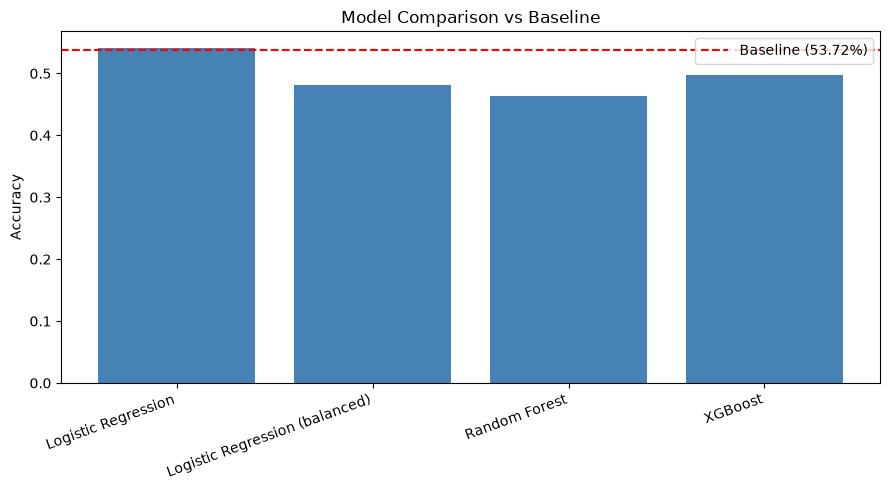

In [2]:
plt.figure(figsize=(9,5))
plt.bar(results_df["model"], results_df["accuracy"], color="steelblue")
plt.axhline(results_df["baseline"].iloc[0], color="red", linestyle="--", label="Baseline (53.72%)")
plt.ylabel("Accuracy")
plt.title("Model Comparison vs Baseline")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions

- None of the three model families (Logistic Regression, Random Forest, XGBoost) 
  meaningfully beat the majority-class baseline of 53.72% on the held-out test period.
- The unbalanced Logistic Regression's near-baseline accuracy (54.09%) was misleading: 
  it achieved this by predicting "Up" for 97% of test samples, not by learning real signal.
  Class-balanced Logistic Regression exposed this, dropping to 48.14%.
- Random Forest and XGBoost, which can capture nonlinear relationships, also failed to 
  beat baseline (46.28-49.81%), and feature importances were evenly spread across all 
  four features rather than concentrated — indicating no single indicator (or their 
  interactions) carries meaningful predictive power for next-day direction.
- This is consistent with the near-zero linear correlations observed during EDA 
  (Stage 3) between all four features and the target.
- **Likely cause:** daily index direction is close to a random walk, and technical 
  indicators derived purely from price/volume (without external signals like news, 
  macro data, or order flow) carry very limited next-day predictive information — 
  a well-documented finding in quantitative finance (weak-form market efficiency).
- **Future directions:** incorporate macroeconomic indicators, sentiment/news data, 
  longer or shorter prediction horizons, or reframe as a magnitude/volatility 
  prediction task rather than binary direction.

In [3]:
results_df.to_csv("../data/processed/final_model_comparison.csv", index=False)